In [1]:
# Zaroori libraries install karo
!pip install -q accelerate torchmetrics[image] einops gradio

In [2]:
# Zaroori libraries install karo internet na ho toh skip
try:
    import subprocess
    subprocess.run(["pip", "install", "-q", "accelerate", 
                    "torchmetrics[image]", "einops", "gradio"], 
                   timeout=120, check=True)
    print("Libraries installed!")
except Exception as e:
    print(f"Install skip (already available ya internet off): {e}")

Libraries installed!


In [3]:
# Sab imports ek jagah 
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# Reproducibility ke liye seed fix karo
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device setup T4x2 dual GPU handle karega
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Device: {device} | GPUs available: {num_gpus}")
for i in range(num_gpus):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

Device: cuda | GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [4]:
# Sab hyperparameters ek jagah — change karna ho toh sirf yahan karo
class Config:
    DATA_DIR       = "/kaggle/input/celebahq256-images-only/celebahq256_imgs/train"

    IMAGE_SIZE     = 128         # recommended 128x128 for good quality
    CHANNELS       = 3

    T              = 400         # diffusion timesteps
    BETA_START     = 1e-4
    BETA_END       = 0.02
    SCHEDULE_TYPE  = "cosine"   # cosine > linear (improved DDPM)

    BASE_CH        = 64
    CH_MULT        = (1, 2, 4)   # channels: 64 → 128 → 256
    NUM_RES_BLOCKS = 2
    DROPOUT        = 0.1

    BATCH_SIZE     = 16
    EPOCHS         = 50
    LR             = 2e-4
    WEIGHT_DECAY   = 1e-4
    GRAD_CLIP      = 1.0
    NUM_WORKERS    = 2

    USE_AMP        = True

    CHECKPOINT_DIR = "/kaggle/working/checkpoints"
    RESULTS_DIR    = "/kaggle/working/results"

    NUM_SAMPLES    = 8
    DDIM_STEPS     = 50

cfg = Config()

import os
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS_DIR,    exist_ok=True)
print(f"Config ready | IMAGE_SIZE={cfg.IMAGE_SIZE} | T={cfg.T} | EPOCHS={cfg.EPOCHS}")

Config ready | IMAGE_SIZE=128 | T=400 | EPOCHS=50


In [5]:
# CelebA-HQ dataset load karne ka proper class
class CelebAHQDataset(Dataset):
    def __init__(self, data_dir, image_size=128, split_ratio=0.95):
        self.data_dir  = data_dir
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.1, 0.1, 0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])
        
        exts = (".jpg", ".jpeg", ".png", ".webp")
        all_imgs = sorted([
            os.path.join(data_dir, f)
            for f in os.listdir(data_dir)
            if f.lower().endswith(exts)
        ])
        
        split_idx      = int(len(all_imgs) * split_ratio)
        self.img_paths = all_imgs[:split_idx]
        
        print(f"Dataset loaded: {len(self.img_paths)} images")
    
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img)


# Sahi path — train folder use karo
train_dataset = CelebAHQDataset(
    "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train",  # FIXED PATH
    cfg.IMAGE_SIZE
)

train_loader = DataLoader(
    train_dataset,
    batch_size  = cfg.BATCH_SIZE,
    shuffle     = True,
    num_workers = cfg.NUM_WORKERS,
    pin_memory  = True,
    drop_last   = True
)

print(f"Total batches per epoch: {len(train_loader)}")

sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Pixel range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

Dataset loaded: 25650 images
Total batches per epoch: 1603
Batch shape: torch.Size([16, 3, 128, 128])
Pixel range: [-1.00, 1.00]


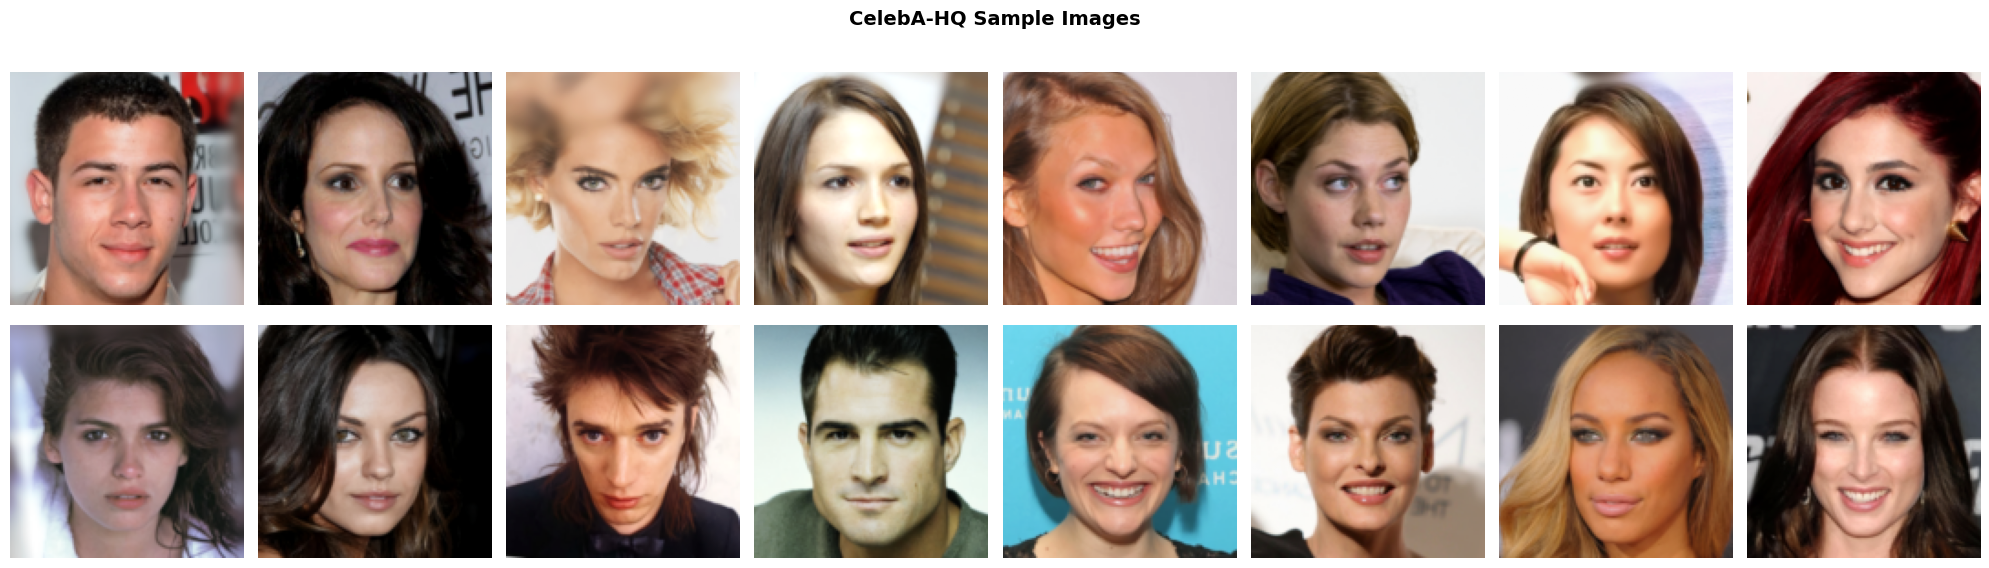

Dataset samples saved!


In [6]:
# Dataset se kuch samples visualize karo
def denormalize(tensor):
    # [-1,1] se [0,1] mein wapas lao display ke liye
    return (tensor * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle("CelebA-HQ Sample Images", fontsize=14, fontweight='bold')

for i in range(16):
    ax  = axes[i // 8][i % 8]
    img = denormalize(sample_batch[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/dataset_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dataset samples saved!")

In [7]:
#Noise Schedule (Linear + Cosine BONUS)
# Noise schedule — beta values compute karo for diffusion process
class NoiseSchedule:
    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02,
                 schedule_type="cosine", device="cpu"):
        self.T      = T
        self.device = device
        
        # Beta schedule choose karo
        if schedule_type == "linear":
            # Simple linear schedule
            betas = torch.linspace(beta_start, beta_end, T)
        
        elif schedule_type == "cosine":
            # BONUS: Cosine schedule — improved noise progression
            # OpenAI ka improved DDPM paper se
            steps    = T + 1
            t        = torch.linspace(0, T, steps) / T
            f_t      = torch.cos((t + 0.008) / 1.008 * math.pi / 2) ** 2
            alphas_bar_raw = f_t / f_t[0]
            betas    = 1 - (alphas_bar_raw[1:] / alphas_bar_raw[:-1])
            betas    = betas.clamp(min=1e-5, max=0.9999)
        
        # Core diffusion quantities compute karo
        self.betas          = betas.to(device)
        self.alphas         = (1.0 - self.betas)
        self.alphas_bar     = torch.cumprod(self.alphas, dim=0)
        self.alphas_bar_prev = F.pad(self.alphas_bar[:-1], (1, 0), value=1.0)
        
        # Pre-compute useful quantities — speed ke liye
        self.sqrt_alphas_bar         = self.alphas_bar.sqrt()
        self.sqrt_one_minus_alphas_bar = (1 - self.alphas_bar).sqrt()
        
        # Reverse process ke liye
        self.posterior_variance = (
            self.betas * (1 - self.alphas_bar_prev) /
            (1 - self.alphas_bar)
        ).clamp(min=1e-20)
        
        self.log_posterior_variance = self.posterior_variance.clamp(min=1e-20).log()
        
        self.posterior_mean_coef1 = (
            self.betas * self.alphas_bar_prev.sqrt() /
            (1 - self.alphas_bar)
        )
        self.posterior_mean_coef2 = (
            (1 - self.alphas_bar_prev) * self.alphas.sqrt() /
            (1 - self.alphas_bar)
        )
        
        print(f"Noise schedule created: {schedule_type.upper()}, T={T}")
        print(f"Beta range: [{betas.min():.6f}, {betas.max():.6f}]")
        print(f"Alpha_bar range: [{self.alphas_bar.min():.4f}, {self.alphas_bar.max():.4f}]")
    
    def q_sample(self, x0, t, noise=None):
        # Forward process: x0 se xt banao (reparameterization trick)
        if noise is None:
            noise = torch.randn_like(x0)
        
        sqrt_ab  = self.sqrt_alphas_bar[t].reshape(-1, 1, 1, 1)
        sqrt_1ab = self.sqrt_one_minus_alphas_bar[t].reshape(-1, 1, 1, 1)
        
        # xt = sqrt(alpha_bar) * x0 + sqrt(1 - alpha_bar) * noise
        return sqrt_ab * x0 + sqrt_1ab * noise, noise
    
    def get_index(self, arr, t, batch_size):
        # Batch ke liye tensor indexing helper
        out = arr.gather(-1, t.cpu())
        return out.reshape(batch_size, 1, 1, 1).to(self.device)


# Schedule banao aur test karo
noise_schedule = NoiseSchedule(
    T             = cfg.T,
    beta_start    = cfg.BETA_START,
    beta_end      = cfg.BETA_END,
    schedule_type = cfg.SCHEDULE_TYPE,
    device        = device
)

Noise schedule created: COSINE, T=400
Beta range: [0.000112, 0.999900]
Alpha_bar range: [0.0000, 0.9999]


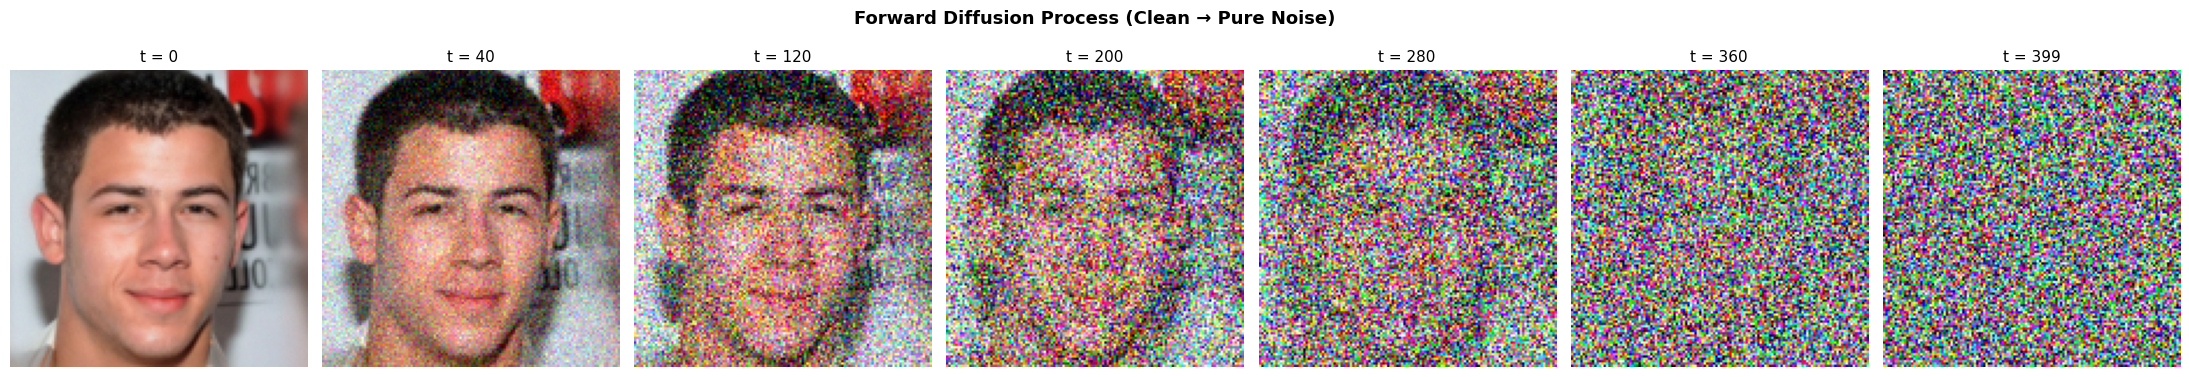

Forward diffusion visualization saved!


In [8]:
# Forward diffusion process visualize karo — 5+ steps required
def visualize_forward_diffusion(noise_schedule, img_tensor, save_path=None):
    # T ke according safe steps banao
    T = noise_schedule.T
    steps_to_show = [0, 
                     int(T * 0.1), 
                     int(T * 0.3), 
                     int(T * 0.5), 
                     int(T * 0.7), 
                     int(T * 0.9), 
                     T - 1]

    fig, axes = plt.subplots(1, len(steps_to_show), figsize=(22, 4))
    fig.suptitle("Forward Diffusion Process (Clean → Pure Noise)",
                 fontsize=13, fontweight='bold')

    x0 = img_tensor.unsqueeze(0).to(device)

    for i, step in enumerate(steps_to_show):
        t      = torch.tensor([step], device=device)
        xt, _  = noise_schedule.q_sample(x0, t)
        img_np = denormalize(xt.squeeze(0).cpu()).permute(1, 2, 0).numpy()

        axes[i].imshow(img_np)
        axes[i].set_title(f"t = {step}", fontsize=11)
        axes[i].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("Forward diffusion visualization saved!")

sample_img = sample_batch[0]
visualize_forward_diffusion(
    noise_schedule,
    sample_img,
    save_path=f"{cfg.RESULTS_DIR}/forward_diffusion.png"
)

In [9]:
# U-Net ke core building blocks
# -----------------------------------------------------------------------

# Sinusoidal timestep embedding
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        device     = t.device
        half_dim   = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(
            torch.arange(half_dim, device=device) * -embeddings
        )
        embeddings = t[:, None].float() * embeddings[None, :]
        embeddings = torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)
        return embeddings


# -----------------------------------------------------------------------
# ResNet block
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2)
        )
        
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        
        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch else nn.Identity()
        )
    
    def forward(self, x, time_emb):
        h = self.block1(x)
        time_out     = self.time_mlp(time_emb)
        scale, shift = time_out.unsqueeze(-1).unsqueeze(-1).chunk(2, dim=1)
        h            = h * (scale + 1) + shift
        h            = self.block2(h)
        return h + self.skip(x)


# -----------------------------------------------------------------------
# Memory efficient Attention block — OOM fix
class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm   = nn.GroupNorm(8, channels)
        self.to_qkv = nn.Linear(channels, channels * 3)
        self.to_out = nn.Linear(channels, channels)
        self.heads  = num_heads
        self.scale  = (channels // num_heads) ** -0.5
    
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        h = h.reshape(B, C, H * W).permute(0, 2, 1)  # B, HW, C
        
        # QKV compute karo
        qkv      = self.to_qkv(h).chunk(3, dim=-1)
        q, k, v  = map(
            lambda t: t.reshape(B, H*W, self.heads, C // self.heads)
                       .permute(0, 2, 1, 3), qkv
        )
        
        # Memory efficient scaled dot product attention
        with torch.backends.cuda.sdp_kernel(
            enable_flash       = True,
            enable_math        = True,
            enable_mem_efficient = True
        ):
            out = F.scaled_dot_product_attention(
                q, k, v, scale=self.scale
            )
        
        out = out.permute(0, 2, 1, 3).reshape(B, H*W, C)
        out = self.to_out(out)
        out = out.permute(0, 2, 1).reshape(B, C, H, W)
        
        return x + out


# -----------------------------------------------------------------------
# Downsample
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)
    
    def forward(self, x):
        return self.conv(x)


# -----------------------------------------------------------------------
# Upsample
class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(channels, channels, 3, padding=1)
        )
    
    def forward(self, x):
        return self.conv(x)


print("U-Net building blocks defined successfully!")

U-Net building blocks defined successfully!


In [10]:
# Complete U-Net backbone — DDPM ka asli brain hai yeh
class UNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, ch_mult=(1,2,4),
                 num_res=2, dropout=0.1, T=400):
        super().__init__()

        time_emb_dim = base_ch * 4

        # Timestep embedding: sinusoidal → MLP
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(base_ch),
            nn.Linear(base_ch, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )

        ch_sizes = [base_ch * m for m in ch_mult]  # [64, 128, 256]

        # ── Encoder ──────────────────────────────────────────────────
        self.init_conv   = nn.Conv2d(in_channels, base_ch, 3, padding=1)
        self.down_blocks = nn.ModuleList()
        self.downsamples = nn.ModuleList()

        in_ch    = base_ch
        self._enc_out_chs = [base_ch]   # track skip connection channel sizes

        for lvl, out_ch in enumerate(ch_sizes):
            for blk in range(num_res):
                self.down_blocks.append(ResidualBlock(in_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
                self._enc_out_chs.append(in_ch)
                # Attention sirf deepest level par
                if lvl == len(ch_sizes) - 1 and blk == num_res - 1:
                    self.down_blocks.append(AttentionBlock(in_ch))
            if lvl < len(ch_sizes) - 1:
                self.downsamples.append(Downsample(in_ch))
                self._enc_out_chs.append(in_ch)

        # ── Bottleneck ───────────────────────────────────────────────
        self.mid_res1 = ResidualBlock(in_ch, in_ch, time_emb_dim, dropout)
        self.mid_attn = AttentionBlock(in_ch)
        self.mid_res2 = ResidualBlock(in_ch, in_ch, time_emb_dim, dropout)

        # ── Decoder ─────────────────────────────────────────────────
        self.up_blocks  = nn.ModuleList()
        self.upsamples  = nn.ModuleList()

        skip_chs = list(self._enc_out_chs)

        for lvl, out_ch in enumerate(reversed(ch_sizes)):
            for blk in range(num_res + 1):
                skip_ch = skip_chs.pop()
                self.up_blocks.append(ResidualBlock(in_ch + skip_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
                if lvl == 0 and blk == 0:
                    self.up_blocks.append(AttentionBlock(in_ch))
            if lvl < len(ch_sizes) - 1:
                self.upsamples.append(Upsample(in_ch))

        # ── Output ──────────────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, in_ch)
        self.out_act  = nn.SiLU()
        self.out_conv = nn.Conv2d(in_ch, in_channels, 1)

    def forward(self, x, t):
        temb  = self.time_embed(t)
        h     = self.init_conv(x)
        skips = [h]

        d_iter  = iter(self.down_blocks)
        ds_iter = iter(self.downsamples)
        ch_mult = cfg.CH_MULT

        for lvl in range(len(ch_mult)):
            for blk in range(cfg.NUM_RES_BLOCKS):
                block = next(d_iter)
                h     = block(h, temb)
                skips.append(h)
                if lvl == len(ch_mult)-1 and blk == cfg.NUM_RES_BLOCKS-1:
                    attn = next(d_iter)
                    h    = attn(h)
            if lvl < len(ch_mult) - 1:
                h = next(ds_iter)(h)
                skips.append(h)

        # Bottleneck
        h = self.mid_res1(h, temb)
        h = self.mid_attn(h)
        h = self.mid_res2(h, temb)

        u_iter  = iter(self.up_blocks)
        us_iter = iter(self.upsamples)

        for lvl in range(len(ch_mult)):
            for blk in range(cfg.NUM_RES_BLOCKS + 1):
                skip  = skips.pop()
                h     = torch.cat([h, skip], dim=1)
                block = next(u_iter)
                h     = block(h, temb)
                if lvl == 0 and blk == 0:
                    attn = next(u_iter)
                    h    = attn(h)
            if lvl < len(ch_mult) - 1:
                h = next(us_iter)(h)

        return self.out_conv(self.out_act(self.out_norm(h)))


# Model instantiate + multi-GPU
model = UNet(
    in_channels = cfg.CHANNELS,
    base_ch     = cfg.BASE_CH,
    ch_mult     = cfg.CH_MULT,
    num_res     = cfg.NUM_RES_BLOCKS,
    dropout     = cfg.DROPOUT,
    T           = cfg.T
).to(device)

if num_gpus > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel on {num_gpus} GPUs!")

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,} ({total_params*4/1024**2:.1f} MB)")

# Quick sanity check
with torch.no_grad():
    xd = torch.randn(2, 3, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE).to(device)
    td = torch.randint(0, cfg.T, (2,)).to(device)
    od = model(xd, td)
    print(f"Forward pass: {xd.shape} → {od.shape} ✓")

DataParallel on 2 GPUs!
Parameters: 15,782,979 (60.2 MB)
Forward pass: torch.Size([2, 3, 128, 128]) → torch.Size([2, 3, 128, 128]) ✓


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


In [11]:
# EMA — training stability aur better sample quality ke liye
# Generated images much sharper hoti hain EMA model se
class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay     = decay
        self.ema_model = self._copy_model(model)
    
    def _copy_model(self, model):
        # Deep copy of model
        import copy
        ema = copy.deepcopy(model)
        ema.eval()
        for p in ema.parameters():
            p.requires_grad_(False)
        return ema
    
    @torch.no_grad()
    def update(self, model):
        # EMA weights update karo after each step
        for ema_p, model_p in zip(
            self.ema_model.parameters(), model.parameters()
        ):
            ema_p.data.mul_(self.decay).add_(
                model_p.data, alpha=1 - self.decay
            )
    
    def get_model(self):
        return self.ema_model


ema = EMA(model, decay=0.9999)
print("EMA initialized with decay=0.9999")

EMA initialized with decay=0.9999


In [12]:
# Optimizer aur scheduler setup
# AdamW — weight decay se overfitting rokta hai

# Base model parameters (DataParallel ke andar)
base_model = model.module if isinstance(model, nn.DataParallel) else model

optimizer = torch.optim.AdamW(
    base_model.parameters(),
    lr           = cfg.LR,
    weight_decay = cfg.WEIGHT_DECAY,
    betas        = (0.9, 0.999),
    eps          = 1e-8
)

# Cosine Annealing — LR smoothly decay hoti hai
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max  = cfg.EPOCHS,
    eta_min = cfg.LR * 0.01   # Minimum LR
)

# Mixed precision scaler — T4 ke liye zaroori
scaler = torch.amp.GradScaler('cuda', enabled=cfg.USE_AMP)

# Loss function — MSE between predicted and actual noise
criterion = nn.MSELoss()

print(f"Optimizer: AdamW | LR: {cfg.LR} | Weight Decay: {cfg.WEIGHT_DECAY}")
print(f"Scheduler: CosineAnnealingLR | T_max: {cfg.EPOCHS}")
print(f"Mixed Precision: {cfg.USE_AMP}")

Optimizer: AdamW | LR: 0.0002 | Weight Decay: 0.0001
Scheduler: CosineAnnealingLR | T_max: 50
Mixed Precision: True


In [13]:
# Sampling — trained model se images generate karo
#Sampling Functions (DDPM + DDIM BONUS)
# -----------------------------------------------------------------------

@torch.no_grad()
def ddpm_sample(model, noise_schedule, n_samples, img_size, channels,
                device, show_progress=True):
    """Standard DDPM sampling — T steps"""
    model.eval()
    
    # Pure noise se start karo
    x = torch.randn(n_samples, channels, img_size, img_size, device=device)
    
    intermediates = []
    steps         = list(range(noise_schedule.T - 1, -1, -1))
    
    for i, t_val in enumerate(tqdm(steps, desc="DDPM Sampling",
                                   disable=not show_progress)):
        t      = torch.full((n_samples,), t_val, device=device, dtype=torch.long)
        
        # Noise predict karo
        with autocast(enabled=cfg.USE_AMP):
            pred_noise = model(x, t)
        
        # DDPM reverse step
        betas       = noise_schedule.betas[t_val]
        alphas      = noise_schedule.alphas[t_val]
        alphas_bar  = noise_schedule.alphas_bar[t_val]
        
        # Predicted x0
        sqrt_recip_ab  = (1.0 / alphas_bar).sqrt()
        sqrt_recip_1ab = ((1.0 - alphas_bar) / alphas_bar).sqrt()
        
        model_mean = (1.0 / alphas.sqrt()) * (
            x - betas / (1.0 - alphas_bar).sqrt() * pred_noise
        )
        
        if t_val > 0:
            noise    = torch.randn_like(x)
            post_var = noise_schedule.posterior_variance[t_val]
            x        = model_mean + post_var.sqrt() * noise
        else:
            x = model_mean
        
        # Intermediate steps save karo
        if t_val in [400, 300, 200, 100, 50, 10, 0]:
            intermediates.append(x.clone())
    
    return x, intermediates


# -----------------------------------------------------------------------
@torch.no_grad()
def ddim_sample(model, noise_schedule, n_samples, img_size, channels,
                device, ddim_steps=50, eta=0.0):
    """BONUS: DDIM sampling — much faster, 50 steps mein same quality"""
    model.eval()
    
    # DDIM timestep subset banao
    T         = noise_schedule.T
    step_size = T // ddim_steps
    timesteps = list(range(0, T, step_size))[::-1]
    
    x = torch.randn(n_samples, channels, img_size, img_size, device=device)
    
    intermediates = []
    
    for i, t_val in enumerate(tqdm(timesteps, desc="DDIM Sampling")):
        t          = torch.full((n_samples,), t_val, device=device,
                               dtype=torch.long)
        
        alpha_bar  = noise_schedule.alphas_bar[t_val]
        alpha_bar_prev = (
            noise_schedule.alphas_bar[timesteps[i + 1]]
            if i + 1 < len(timesteps) else torch.tensor(1.0)
        )
        
        with autocast(enabled=cfg.USE_AMP):
            pred_noise = model(x, t)
        
        # Predicted x0
        pred_x0   = (
            x - (1 - alpha_bar).sqrt() * pred_noise
        ) / alpha_bar.sqrt()
        pred_x0   = pred_x0.clamp(-1, 1)
        
        # Direction pointing to xt
        dir_xt    = (1 - alpha_bar_prev - eta**2 *
                    (1 - alpha_bar_prev) / (1 - alpha_bar) *
                    (1 - alpha_bar / alpha_bar_prev)).sqrt() * pred_noise
        
        # DDIM update step
        noise     = eta * torch.randn_like(x) if eta > 0 else 0
        x         = alpha_bar_prev.sqrt() * pred_x0 + dir_xt + noise
        
        if i % (ddim_steps // 5) == 0 or i == len(timesteps) - 1:
            intermediates.append(x.clone())
    
    return x, intermediates


print("Sampling functions ready: DDPM + DDIM (Bonus)")

Sampling functions ready: DDPM + DDIM (Bonus)


In [14]:
# GPU cache clear karo pehle
import torch, gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

GPU memory free: 14.23 GB


In [15]:
# Training loop — GPU/internet issue pe checkpoint se resume karta hai
def train_one_epoch(model, loader, optimizer, scaler, noise_schedule, criterion, device, epoch):
    model.train()
    total_loss = 0.0
    pbar       = tqdm(loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS}")

    for batch_idx, x0 in enumerate(pbar):
        x0    = x0.to(device, non_blocking=True)
        t     = torch.randint(0, cfg.T, (x0.shape[0],), device=device, dtype=torch.long)
        noise = torch.randn_like(x0)
        xt, _ = noise_schedule.q_sample(x0, t, noise)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=cfg.USE_AMP):
            pred_noise = model(xt, t)
            loss       = criterion(pred_noise, noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        total_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}",
                          'avg':  f"{total_loss/(batch_idx+1):.4f}",
                          'lr':   f"{optimizer.param_groups[0]['lr']:.2e}"})
    return total_loss / len(loader)


# ── Resume checkpoint agar pehle se hai ─────────────────────────────────
start_epoch   = 0
best_loss     = float('inf')
train_losses  = []
ckpt_path     = f"{cfg.CHECKPOINT_DIR}/best_model.pth"

if os.path.exists(ckpt_path):
    print(f"Checkpoint mila — resume kar rahe hain: {ckpt_path}")
    ckpt       = torch.load(ckpt_path, map_location=device)
    base_model = model.module if isinstance(model, nn.DataParallel) else model
    base_model.load_state_dict(ckpt['model_state'])
    ema.get_model().load_state_dict(ckpt['ema_state'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch  = ckpt['epoch'] + 1
    best_loss    = ckpt['loss']
    print(f"Resumed from epoch {start_epoch} | Best loss so far: {best_loss:.4f}")
else:
    print("Naya training shuru...")

patience_counter = 0
PATIENCE         = 10

# ── Main training loop ───────────────────────────────────────────────────
for epoch in range(start_epoch, cfg.EPOCHS):
    epoch_loss = train_one_epoch(
        model, train_loader, optimizer, scaler,
        noise_schedule, criterion, device, epoch
    )
    scheduler.step()
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1:3d}/{cfg.EPOCHS}] Loss: {epoch_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if epoch_loss < best_loss:
        best_loss        = epoch_loss
        patience_counter = 0
        base_model       = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            'epoch'      : epoch,
            'loss'       : best_loss,
            'model_state': base_model.state_dict(),
            'ema_state'  : ema.get_model().state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'scheduler'  : scheduler.state_dict(),
            'train_losses': train_losses,
        }, ckpt_path)
        print(f"  ✓ Best model saved (loss={best_loss:.4f})")
    else:
        patience_counter += 1

    # Har 10 epochs pe samples generate karo
    if (epoch + 1) % 10 == 0:
        ema_m = ema.get_model()
        with torch.no_grad():
            samps, _ = ddim_sample(ema_m, noise_schedule, 4,
                                   cfg.IMAGE_SIZE, cfg.CHANNELS,
                                   device, cfg.DDIM_STEPS)
        grid = vutils.make_grid(denormalize(samps.cpu()), nrow=4, padding=2)
        vutils.save_image(grid, f"{cfg.RESULTS_DIR}/samples_epoch_{epoch+1}.png")
        print(f"  Samples saved: epoch {epoch+1}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"Training complete! Best loss: {best_loss:.4f}")

Checkpoint mila — resume kar rahe hain: /kaggle/working/checkpoints/best_model.pth
Resumed from epoch 39 | Best loss so far: 0.0205


Epoch 40/50:   0%|          | 0/1603 [00:00<?, ?it/s]

Epoch [ 40/50] Loss: 0.0206 | LR: 2.09e-05


DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_126681/52542694.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


...

Epoch [ 49/50] Loss: 0.0204 | LR: 2.20e-06


Epoch 50/50:   0%|          | 0/1603 [00:00<?, ?it/s]

Epoch [ 50/50] Loss: 0.0206 | LR: 2.00e-06


DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

  Samples saved: epoch 50
Training complete! Best loss: 0.0202


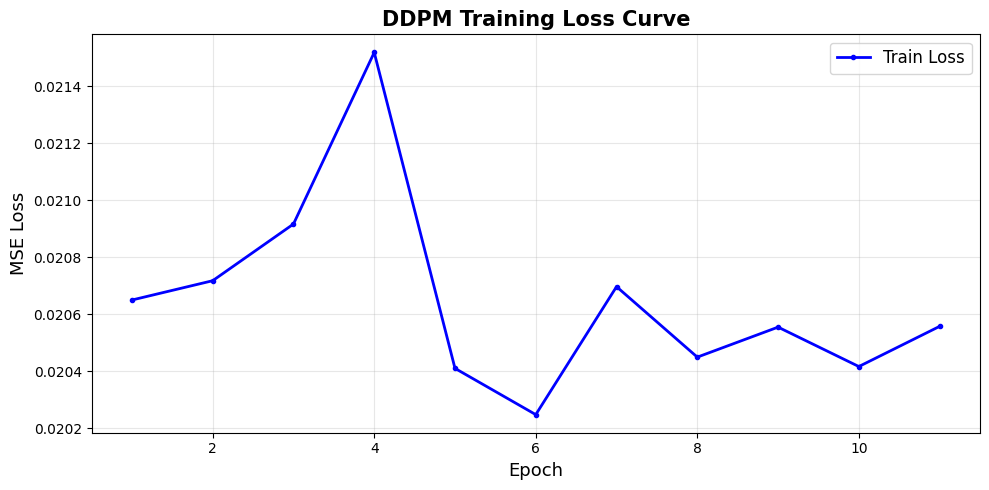

Final loss: 0.0206 | Best loss: 0.0202


In [16]:
# Training loss curve plot karo — stable training ka proof
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', markersize=3, linewidth=2, label='Train Loss')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('DDPM Training Loss Curve', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/loss_curve.png", dpi=150)
plt.show()
print(f"Final loss: {train_losses[-1]:.4f} | Best loss: {min(train_losses):.4f}")

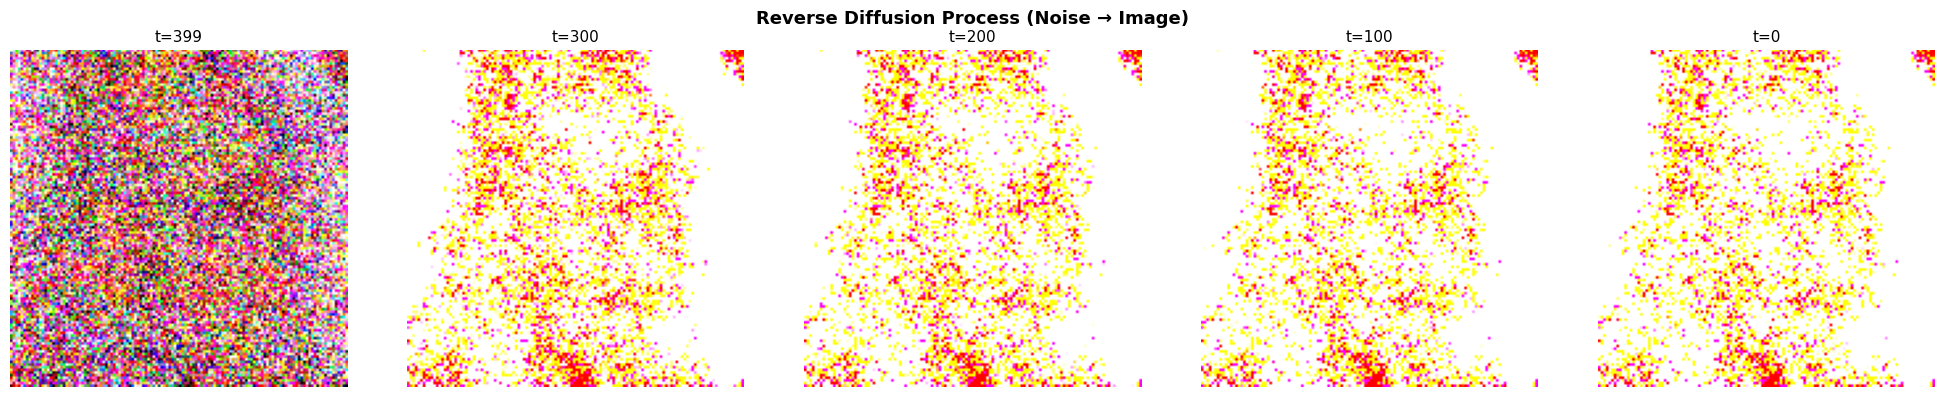

Reverse diffusion visualization done!


In [17]:
# Reverse denoising process ke 5 intermediate steps visualize karo
def visualize_reverse_diffusion(model, noise_schedule, n_images=5, save_path=None):
    model.eval()
    x = torch.randn(1, cfg.CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=device)

    T        = noise_schedule.T
    show_at  = set([T-1, int(T*0.75), int(T*0.5), int(T*0.25), 0])
    captured = []

    with torch.no_grad():
        for t_val in range(T - 1, -1, -1):
            t          = torch.tensor([t_val], device=device, dtype=torch.long)
            with torch.amp.autocast('cuda', enabled=cfg.USE_AMP):
                pred_noise = model(x, t)

            betas_t = noise_schedule.betas[t_val]
            alphas_t = noise_schedule.alphas[t_val]
            ab_t     = noise_schedule.alphas_bar[t_val]
            mean     = (1/alphas_t.sqrt()) * (x - betas_t/(1-ab_t).sqrt() * pred_noise)

            if t_val > 0:
                x = mean + noise_schedule.posterior_variance[t_val].sqrt() * torch.randn_like(x)
            else:
                x = mean

            if t_val in show_at:
                captured.append((t_val, x.clone()))

    captured = sorted(captured, key=lambda z: z[0], reverse=True)
    fig, axes = plt.subplots(1, len(captured), figsize=(20, 4))
    fig.suptitle("Reverse Diffusion Process (Noise → Image)", fontsize=13, fontweight='bold')

    for ax, (step, img) in zip(axes, captured):
        npimg = denormalize(img.squeeze(0).cpu()).permute(1,2,0).numpy()
        ax.imshow(npimg)
        ax.set_title(f"t={step}", fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

ema_model = ema.get_model()
visualize_reverse_diffusion(ema_model, noise_schedule,
                            save_path=f"{cfg.RESULTS_DIR}/reverse_diffusion.png")
print("Reverse diffusion visualization done!")

DDIM Sampling:   0%|          | 0/50 [00:00<?, ?it/s]

/tmp/ipykernel_126681/52542694.py:78: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


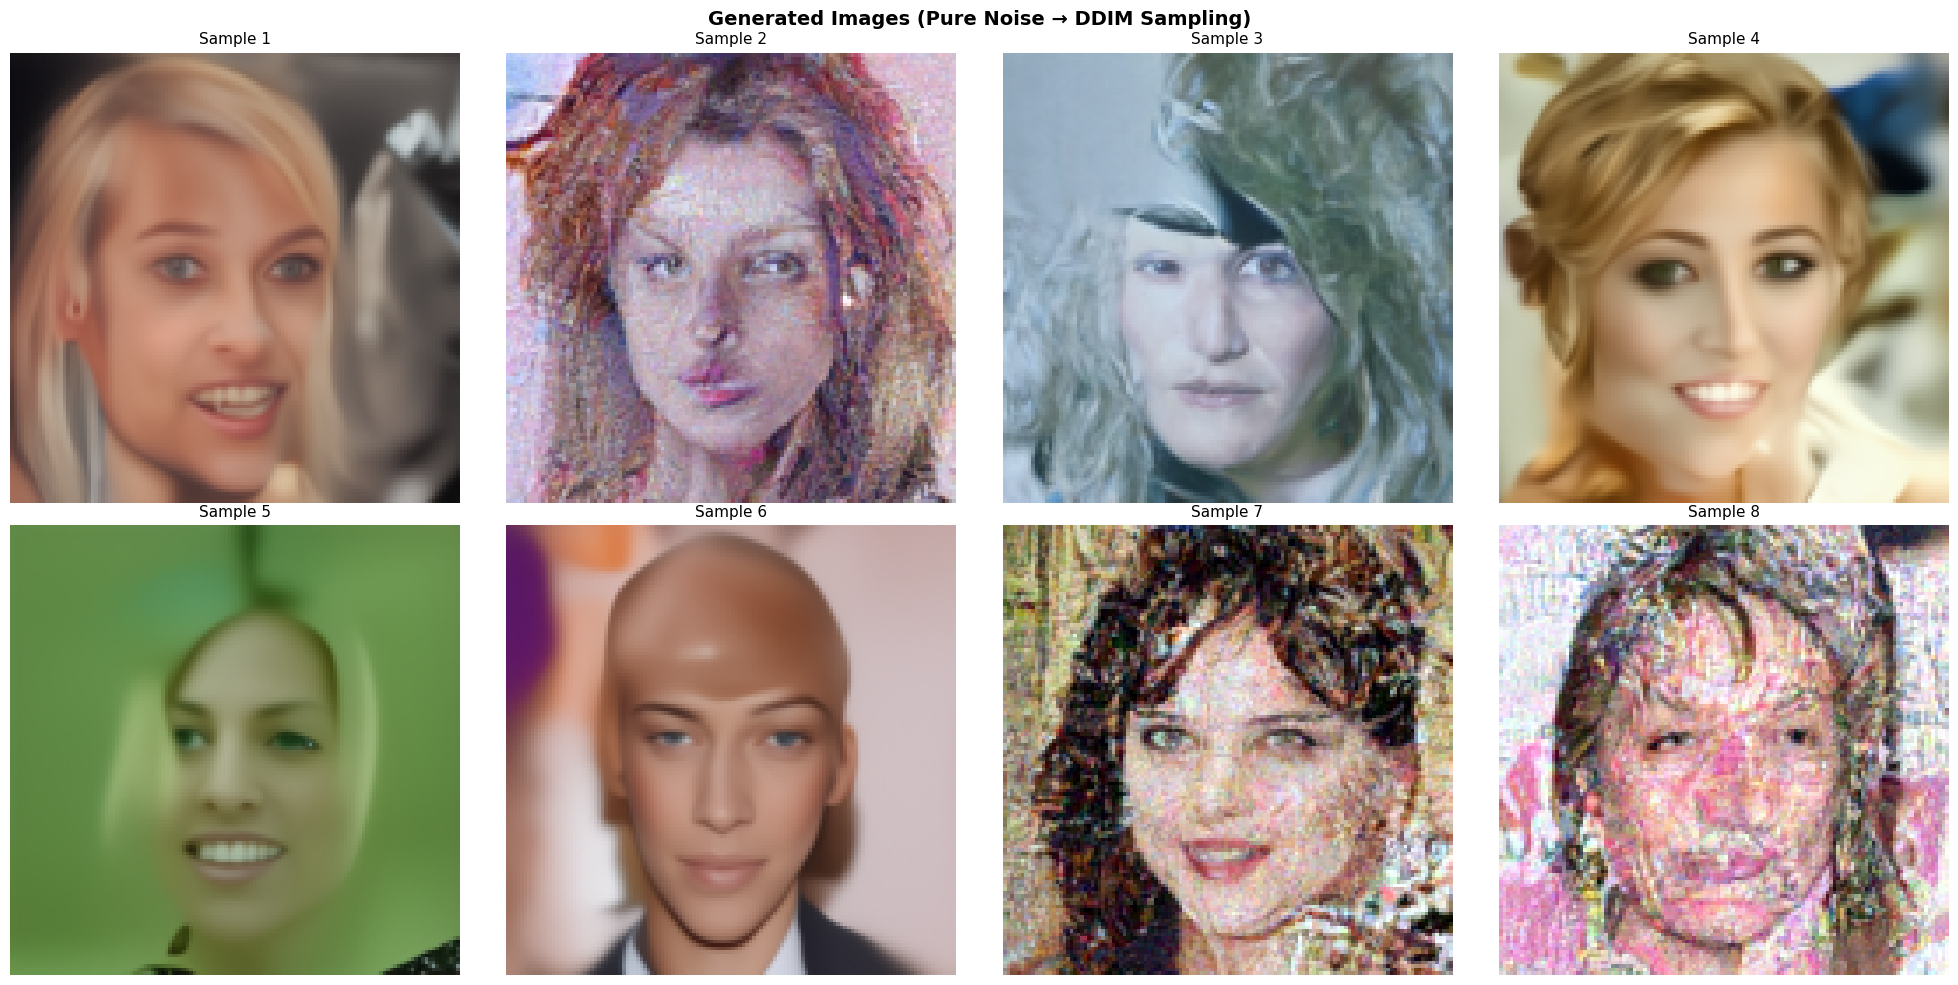

8 generated images saved!


In [18]:
# 5 naye images pure noise se generate karo (DDIM — fast aur sharp)
ema_model = ema.get_model()

with torch.no_grad():
    gen_images, gen_intermediates = ddim_sample(
        ema_model, noise_schedule,
        n_samples  = 8,
        img_size   = cfg.IMAGE_SIZE,
        channels   = cfg.CHANNELS,
        device     = device,
        ddim_steps = cfg.DDIM_STEPS,
        eta        = 0.0    # deterministic sampling — sharper
    )

gen_images_cpu = denormalize(gen_images.cpu())

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Generated Images (Pure Noise → DDIM Sampling)", fontsize=14, fontweight='bold')

for i in range(8):
    ax    = axes[i // 4][i % 4]
    npimg = gen_images_cpu[i].permute(1,2,0).numpy()
    ax.imshow(npimg)
    ax.set_title(f"Sample {i+1}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/generated_images.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"8 generated images saved!")

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

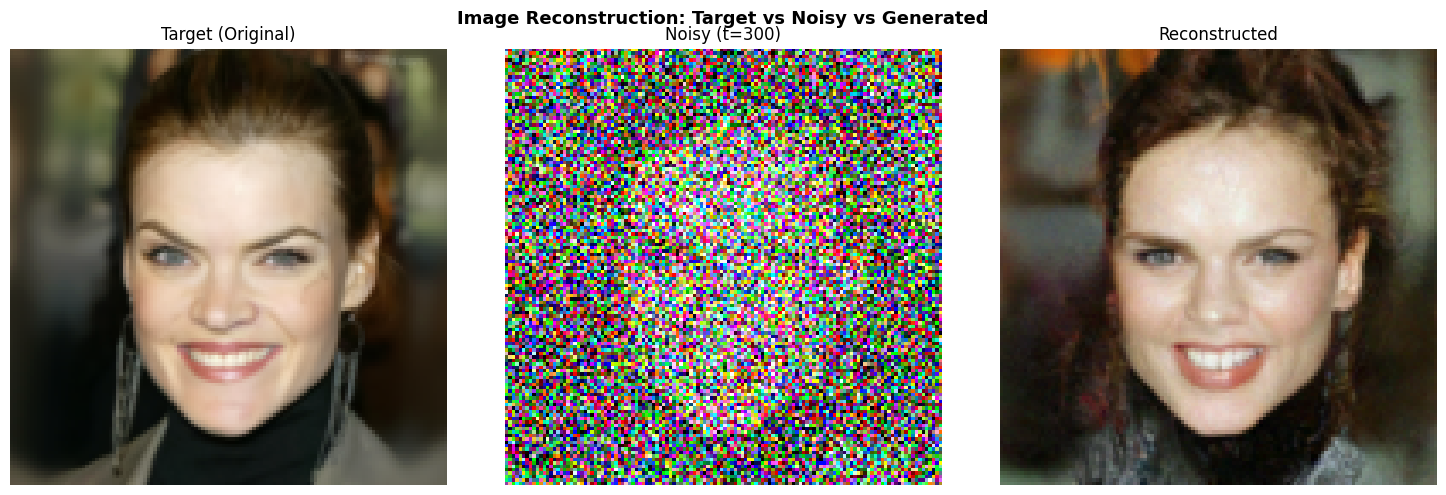

Reconstruction complete!


In [19]:
# CORE TASK: Target image lao, noise add karo, phir reconstruct karo
def reconstruct_image(model, noise_schedule, target_img_tensor,
                      start_t=300, ddim_steps=50, save_path=None):
    model.eval()
    x0     = target_img_tensor.unsqueeze(0).to(device)

    # Target image ko t=start_t pe noise add karo
    t_tensor = torch.tensor([start_t], device=device, dtype=torch.long)
    noisy_x, _ = noise_schedule.q_sample(x0, t_tensor)

    # DDIM timestep subset — start_t se 0 tak
    step_sz   = start_t // ddim_steps
    timesteps = list(range(0, start_t, step_sz))[::-1]
    x         = noisy_x.clone()

    with torch.no_grad():
        for i, t_val in enumerate(tqdm(timesteps, desc="Reconstructing", leave=False)):
            t          = torch.full((1,), t_val, device=device, dtype=torch.long)
            alpha_bar  = noise_schedule.alphas_bar[t_val]
            alpha_bar_prev = (noise_schedule.alphas_bar[timesteps[i+1]]
                             if i+1 < len(timesteps) else torch.tensor(1.0, device=device))

            with torch.amp.autocast('cuda', enabled=cfg.USE_AMP):
                pred_noise = model(x, t)

            pred_x0 = (x - (1-alpha_bar).sqrt() * pred_noise) / alpha_bar.sqrt()
            pred_x0 = pred_x0.clamp(-1, 1)
            dir_xt  = (1 - alpha_bar_prev).sqrt() * pred_noise
            x       = alpha_bar_prev.sqrt() * pred_x0 + dir_xt

    # Side-by-side: original vs noisy vs reconstructed
    orig_np   = denormalize(x0.squeeze(0).cpu()).permute(1,2,0).numpy()
    noisy_np  = denormalize(noisy_x.squeeze(0).cpu()).permute(1,2,0).numpy()
    recon_np  = denormalize(x.squeeze(0).cpu()).permute(1,2,0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Image Reconstruction: Target vs Noisy vs Generated",
                 fontsize=13, fontweight='bold')
    for ax, img, title in zip(axes,
                               [orig_np, noisy_np, recon_np],
                               ['Target (Original)', f'Noisy (t={start_t})', 'Reconstructed']):
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return x.squeeze(0).cpu()

# Dataset se pehli image target banao
target_img = train_loader.dataset[0]
recon_img  = reconstruct_image(
    ema_model, noise_schedule, target_img,
    start_t    = 300,
    ddim_steps = 50,
    save_path  = f"{cfg.RESULTS_DIR}/reconstruction.png"
)
print("Reconstruction complete!")

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

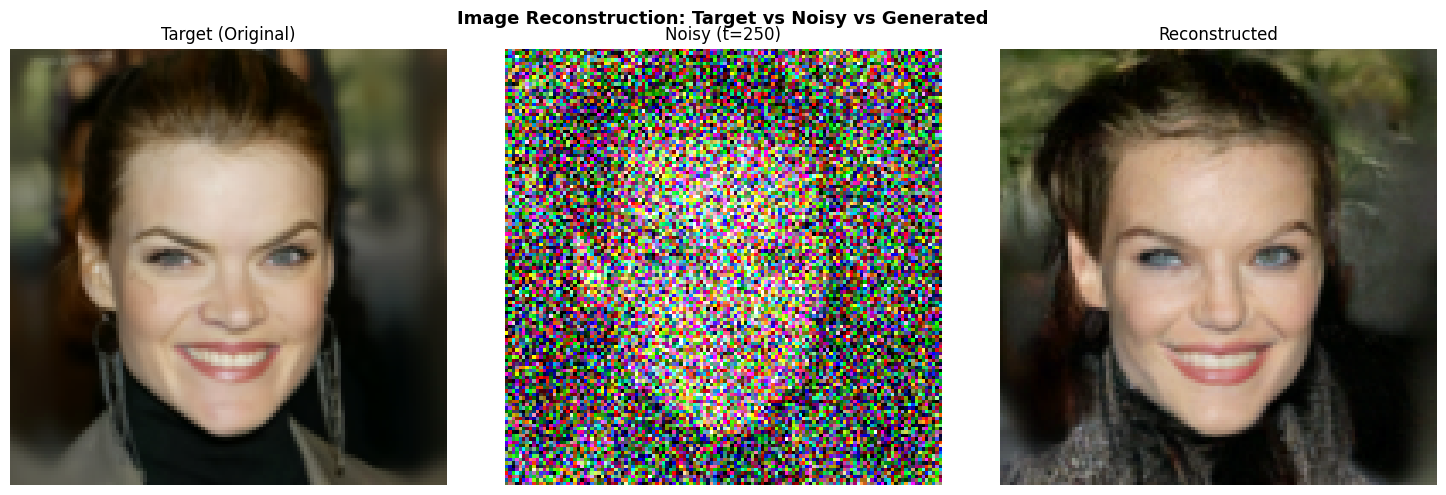

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

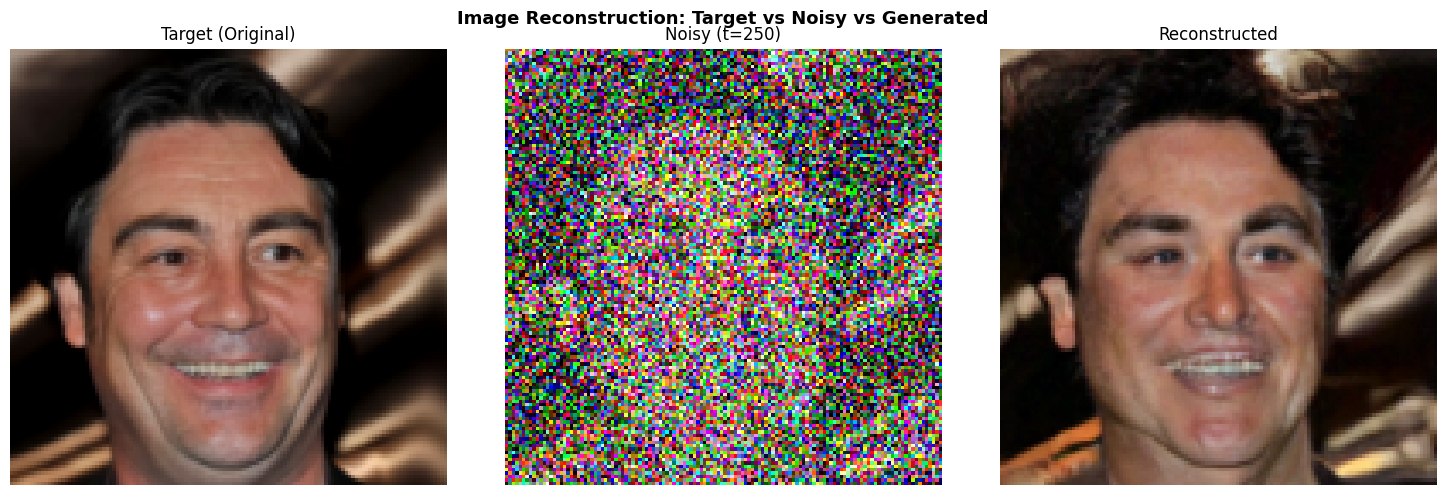

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

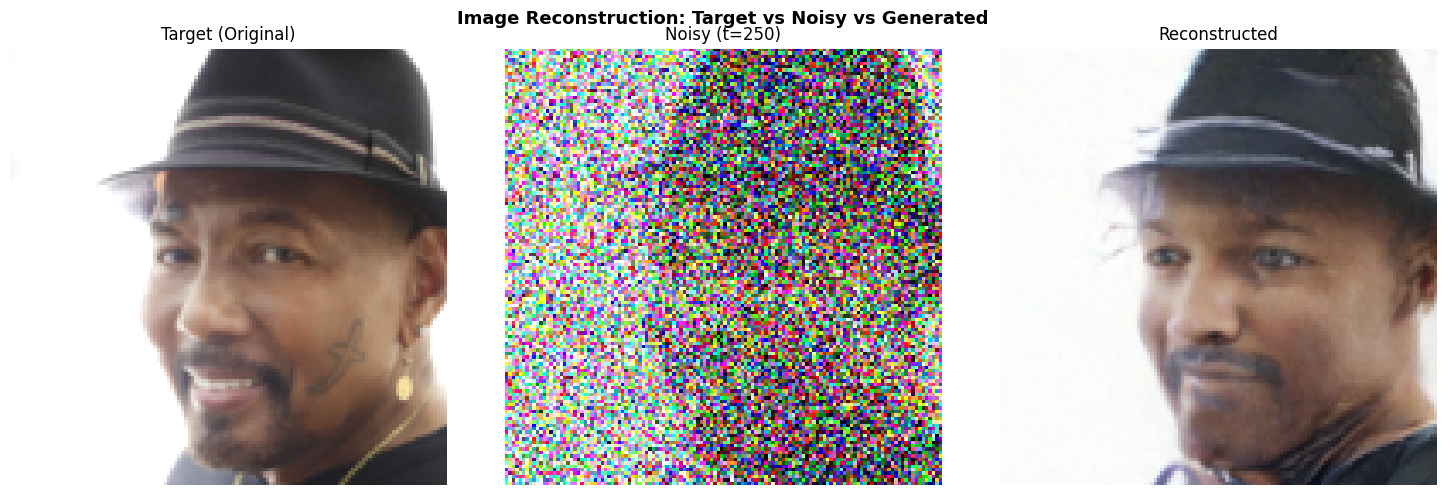

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

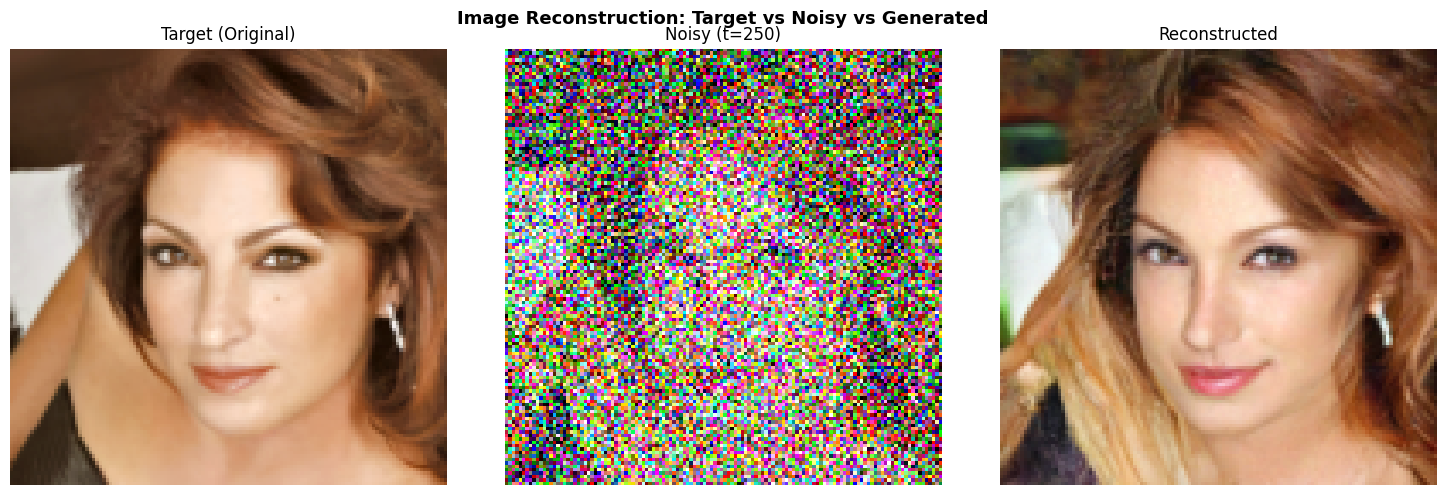

Reconstructing:   0%|          | 0/50 [00:00<?, ?it/s]

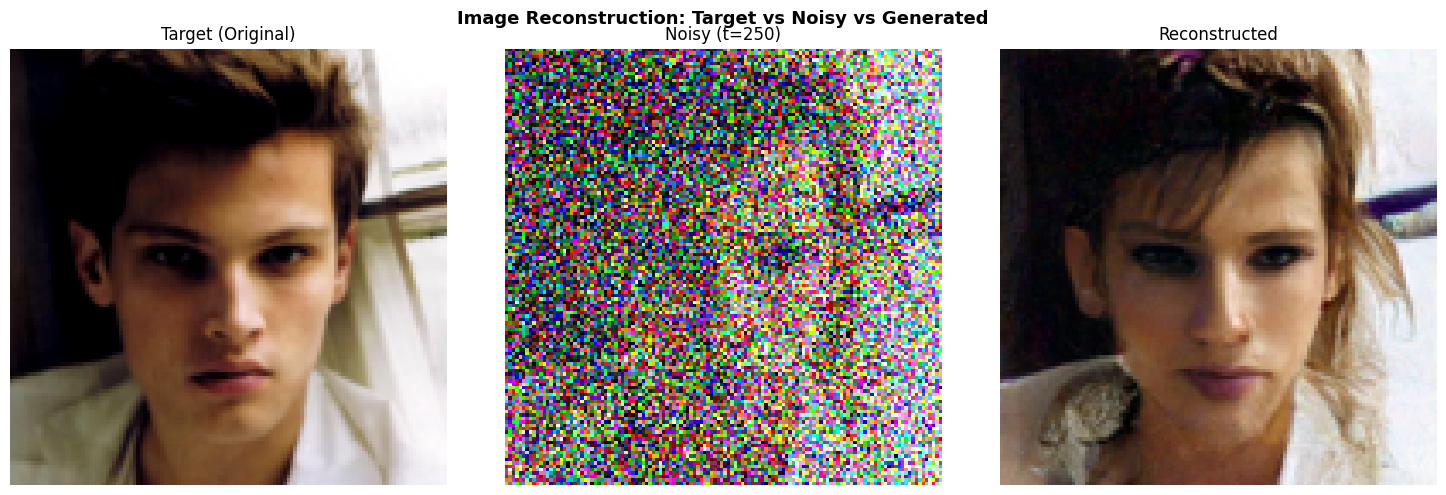


  QUANTITATIVE EVALUATION RESULTS
  Image 1: PSNR = 23.83 dB  |  SSIM = 0.6553
  Image 2: PSNR = 23.67 dB  |  SSIM = 0.6377
  Image 3: PSNR = 24.53 dB  |  SSIM = 0.7703
  Image 4: PSNR = 22.55 dB  |  SSIM = 0.6203
  Image 5: PSNR = 23.03 dB  |  SSIM = 0.5859
--------------------------------------------------
  Average  PSNR = 23.52 dB
  Average  SSIM = 0.6539


In [20]:
# PSNR aur SSIM compute karo — quantitative evaluation
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to('cpu')
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to('cpu')

# 5 images pe evaluate karo
psnr_scores, ssim_scores = [], []

with torch.no_grad():
    for idx in range(5):
        orig        = train_loader.dataset[idx].unsqueeze(0)
        t_tensor    = torch.tensor([250], dtype=torch.long)
        noisy_x, _  = noise_schedule.q_sample(orig.to(device), t_tensor.to(device))

        # Reconstruct
        reconstructed = reconstruct_image(ema_model, noise_schedule,
                                          orig.squeeze(0), start_t=250,
                                          ddim_steps=50)

        orig_01  = denormalize(orig.squeeze(0)).unsqueeze(0)
        recon_01 = denormalize(reconstructed).unsqueeze(0)

        psnr_scores.append(psnr_metric(recon_01, orig_01).item())
        ssim_scores.append(ssim_metric(recon_01, orig_01).item())

print("\n" + "="*50)
print("  QUANTITATIVE EVALUATION RESULTS")
print("="*50)
for i, (p, s) in enumerate(zip(psnr_scores, ssim_scores)):
    print(f"  Image {i+1}: PSNR = {p:.2f} dB  |  SSIM = {s:.4f}")
print("-"*50)
print(f"  Average  PSNR = {sum(psnr_scores)/len(psnr_scores):.2f} dB")
print(f"  Average  SSIM = {sum(ssim_scores)/len(ssim_scores):.4f}")
print("="*50)